# Chemistry Recurrent Neural Network (LSTM) Example
In this example we will return to the delaney dataset. We will use an LSTM that reads the SMILES sequence and then predicts solubility.

# Install Packages
Only run if you do not have packages installed

In [ ]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install torch torchvision torchaudio #note this will install pytorch for CPU

# Load data

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("delaney.csv")

# Create vocabulary for SMILES
We need to identify the characters present in SMILES so the model knows what charcters to expect.
Note that if your testing set has characters not present in training set it will map to an unkown (UNK) character, performance might be bad if unknown characters are common.
You could also try a tokenization strategy where relevant combinations of characters are treated as a single item or token in the sequence, but for simplicity we will do this at the character level

In [3]:
all_smiles = df["SMILES"].tolist()

chars = sorted(set("".join(all_smiles)))

# Reserve 0 for padding, 1 for unknown
stoi = {"<PAD>": 0, "<UNK>": 1}
for i, ch in enumerate(chars, start=2):
    stoi[ch] = i

itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(stoi)

print(f"Vocab size: {vocab_size}")
print("Characters:", chars)

#this method will convert smiles to our vocabulary encoding, will map to UNK if character is not in vocabulary
def encode_smiles(smiles, stoi):
    return [stoi.get(ch, stoi["<UNK>"]) for ch in smiles]

Vocab size: 34
Characters: [' ', '#', '(', ')', '/', '1', '2', '3', '4', '5', '6', '7', '8', '=', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'c', 'l', 'n', 'o', 'r', 's']


# Split training and testing data
Split the data and prepare pytorch Datasets

In [4]:
train_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, random_state=42)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

#this class will contain our data formatted for pytorch
class DelaneySmilesDataset(Dataset):
    def __init__(self, dataframe, stoi):
        self.smiles = dataframe["SMILES"].tolist()
        self.targets = dataframe["measured log(solubility:mol/L)"].astype(np.float32).tolist()
        self.stoi = stoi

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smi = self.smiles[idx]
        x = encode_smiles(smi, self.stoi)
        y = self.targets[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.float32)


train_dataset = DelaneySmilesDataset(train_df, stoi)
val_dataset = DelaneySmilesDataset(val_df, stoi)
test_dataset = DelaneySmilesDataset(test_df, stoi)

#this function will handle sequence of different lengths, it will add padding to make all sequences in a batch the same length
def collate_batch(batch):
    sequences, targets = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)

    padded_sequences = nn.utils.rnn.pad_sequence(
        sequences,
        batch_first=True,
        padding_value=stoi["<PAD>"]
    )

    targets = torch.stack(targets)
    return padded_sequences, lengths, targets

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)


Train: 826
Val:   146
Test:  172


# Train and Test Model

In [5]:
#class for an LSTM regression model
class SmilesLSTMRegressor(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=64,
        hidden_dim=128,
        num_layers=1,
        dropout=0.2,
        pad_idx=0,
        bidirectional=False
    ):
        super().__init__()
        
        #turns input characters into a learned embedding, or representation, for each character
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        
        #set up the LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
    
        #create output layer
        self.regressor = nn.Sequential(
            nn.Linear(lstm_output_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    #forward method predicts the output
    def forward(self, x, lengths):
        # x shape: (batch, seq_len)
        embedded = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (h_n, c_n) = self.lstm(packed)

        # h_n shape:
        #   unidirectional: (num_layers, batch, hidden_dim)
        #   bidirectional: (num_layers*2, batch, hidden_dim)
        if self.lstm.bidirectional:
            # concatenate final forward + backward hidden states
            final_hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            final_hidden = h_n[-1]

        out = self.regressor(final_hidden).squeeze(1)
        return out


#set up the model and training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#create the model, you can try adjusting hyperparameters like the embedding and hidden dimensions
#you can also try adding multiple layers which will run the output of the one LSTM through a second LSTM
model = SmilesLSTMRegressor(
    vocab_size=vocab_size,
    embedding_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.2,
    pad_idx=stoi["<PAD>"],
    bidirectional=True
).to(device)

criterion = nn.MSELoss() #MSELoss for regression
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    preds_all = []
    targets_all = []

    for x, lengths, y in loader:
        x = x.to(device)
        lengths = lengths.to(device)
        y = y.to(device)

        if training:
            optimizer.zero_grad()

        preds = model(x, lengths)
        loss = criterion(preds, y)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds_all.append(preds.detach().cpu().numpy())
        targets_all.append(y.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all)
    targets_all = np.concatenate(targets_all)

    rmse = np.sqrt(mean_squared_error(targets_all, preds_all))
    r2 = r2_score(targets_all, preds_all)
    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, rmse, r2


#train model
num_epochs = 30

for epoch in range(1, num_epochs + 1):
    train_loss, train_rmse, train_r2 = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_rmse, val_r2 = run_epoch(model, val_loader, criterion)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train RMSE: {train_rmse:.4f} | Train R2: {train_r2:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val RMSE: {val_rmse:.4f} | Val R2: {val_r2:.4f}"
    )



Using device: cpu
Epoch 01 | Train Loss: 7.8601 | Train RMSE: 2.8036 | Train R2: -0.7742 | Val Loss: 3.7952 | Val RMSE: 1.9481 | Val R2: 0.0862
Epoch 02 | Train Loss: 3.6224 | Train RMSE: 1.9033 | Train R2: 0.1824 | Val Loss: 2.9975 | Val RMSE: 1.7313 | Val R2: 0.2783
Epoch 03 | Train Loss: 2.7140 | Train RMSE: 1.6474 | Train R2: 0.3874 | Val Loss: 2.0436 | Val RMSE: 1.4296 | Val R2: 0.5080
Epoch 04 | Train Loss: 1.7543 | Train RMSE: 1.3245 | Train R2: 0.6040 | Val Loss: 1.6060 | Val RMSE: 1.2673 | Val R2: 0.6133
Epoch 05 | Train Loss: 1.6490 | Train RMSE: 1.2841 | Train R2: 0.6278 | Val Loss: 1.4361 | Val RMSE: 1.1984 | Val R2: 0.6542
Epoch 06 | Train Loss: 1.1820 | Train RMSE: 1.0872 | Train R2: 0.7332 | Val Loss: 1.1681 | Val RMSE: 1.0808 | Val R2: 0.7188
Epoch 07 | Train Loss: 1.1885 | Train RMSE: 1.0902 | Train R2: 0.7317 | Val Loss: 1.0717 | Val RMSE: 1.0352 | Val R2: 0.7420
Epoch 08 | Train Loss: 1.0705 | Train RMSE: 1.0347 | Train R2: 0.7584 | Val Loss: 0.9796 | Val RMSE: 0.989

# Test set evaluation


Test performance
Test Loss: 0.4952
Test RMSE: 0.7037
Test R2:   0.8876


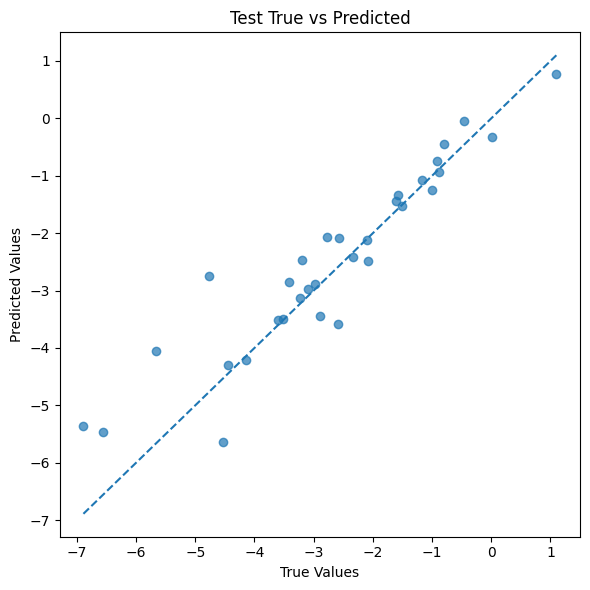

In [21]:
import matplotlib.pyplot as plt

#test set evaluation
test_loss, test_rmse, test_r2 = run_epoch(model, test_loader, criterion)

print("\nTest performance")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R2:   {test_r2:.4f}")

#get the actual predictions
all_preds = np.zeros(0)
all_true = np.zeros(0)
for x, lengths, y in test_loader:
    x = x.to(device)
    lengths = lengths.to(device)
    y = y.to(device)
    model.eval()
    optimizer.zero_grad()
    preds = model(x, lengths)
    
    if all_preds.shape[0] == 0:
        all_preds = preds.detach().numpy()
        all_true = y.detach().numpy()
    else:
        np.concatenate((all_preds,preds.detach().numpy()), axis=0)
        np.concatenate((all_true, y.detach().numpy()), axis=0)

plt.figure(figsize=(6, 6))
plt.scatter(all_true, all_preds, alpha=0.7)

min_val = min(all_true.min(), all_preds.min())
max_val = max(all_true.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Test True vs Predicted")
plt.tight_layout()
plt.show()
